# EJERCICIO 23!!    

Un experimento aleatorio consiste en arrojar dos dados equilibrados y anotar la suma de los numeros resultantes en cada uno.

In [31]:
import numpy as np  
import matplotlib.pyplot as plt 

In [32]:
#definimos el espacio muestral de los dados, como la suma de los resultados de tirar dos dados
espacio_muestral = [i+j for i in range(1,7) for j in range(1,7)] #aca usamos [] para definir una lista, y le asignamos condiciones, notemos que usamos range(1,7), ya que el 7 no se incluye en el rango

#aca detectamos que la variable aleatoria es la suma de los resultados de tirar dos dados

# Distribución teórica de la variable aleatoria suma
suma_dados, frec_teorica = np.unique(espacio_muestral,return_counts=True) #np.unique nos devuelve los valores unicos de la lista resultados, recordemos que se repiten por permutaciones, y la frecuencia de cada uno cuandoa gregamos return_counts=True
prob_teorica = frec_teorica / 36  # 36 es el total de combinaciones posibles al tirar dos dados, dividimos para obtener la probabilidad

print ("suma de los dados",suma_dados)
print("probabilidad teorica",prob_teorica)


suma de los dados [ 2  3  4  5  6  7  8  9 10 11 12]
probabilidad teorica [0.02777778 0.05555556 0.08333333 0.11111111 0.13888889 0.16666667
 0.13888889 0.11111111 0.08333333 0.05555556 0.02777778]


# 23d

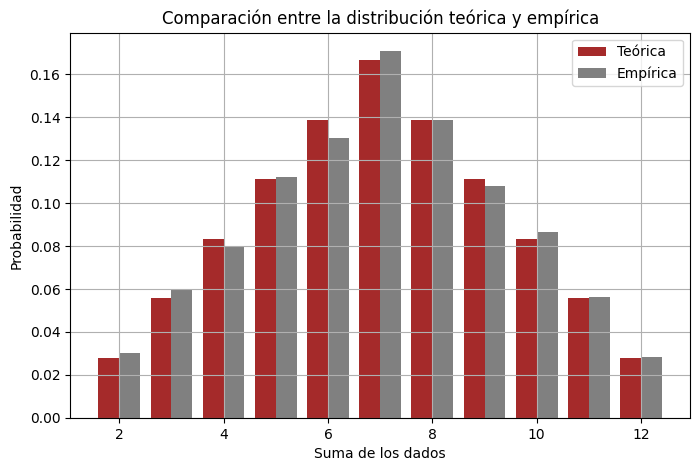

In [46]:
def generador_numeros_enteros(n, a, c, M, x1, low = 1, high = 6): #aca usamos low y high para definir el rango de los numeros generados
    numeros = []
    x = x1
    for i in range(n):
        x = (a * x + c) % M
        # Generar un número entre low y high, ambos inclusivos
        numero = low + int((x / M) * (high - low + 1)) # Usamos int() para asegurarnos de que el número sea un entero y caiga dentro del rango que nos interesa, que es entre 1 y 6
        numeros.append(numero) 
    return numeros


# Parámetros del generador congruencial lineal
a = 1664525
c = 1013904223
M = 2**32
x1 = 10
n = 10000

# Generar dos listas de números aleatorios entre 1 y 6
dado_1 = generador_numeros_enteros(n, a, c, M, x1)
dado_2 = generador_numeros_enteros(n, a, c, M, x1 + 1)  # Cambiamos la semilla para obtener una secuencia diferente


# Sumamos los valores
suma = np.zeros(n) #recordemos, np.zeros(n) crea un array de n elementos inicializados en 0, esto es util para luego ir sumando los valores y agregarlos al array lleno de ceros(vacio), es como cuando creamos una lista con []
for i in range(n):
  suma[i] = dado_1[i] + dado_2[i] #aca agregamos los valores de cada dado en la posicion i, y lo guardamos en la posicion i del array suma, por eso usamos [i], para aclarar en que indice se guarda el valor

# Distribución empírica de la variable aleatoria suma   
suma_emp, frec_emp = np.unique(suma, return_counts=True)
prob_emp = frec_emp / n  # n es el total de tiradas, dividimos para obtener la probabilidad

# Comparar la distribución empírica con la teórica
plt.figure(figsize=(8, 5))
plt.bar(suma_dados - 0.2, prob_teorica, width=0.4, label='Teórica', color='brown')
plt.bar(suma_emp + 0.2, prob_emp, width=0.4, label='Empírica', color='gray')
plt.xlabel('Suma de los dados')
plt.ylabel('Probabilidad')
plt.title('Comparación entre la distribución teórica y empírica')
plt.legend()
plt.grid(True)
plt.show()


# 23c Metodo de la transformacion inversa

Aca tenemos que aplicar algo que no nos enseñaron y esperan que sepamos que es el metodo de la transformacion inversa

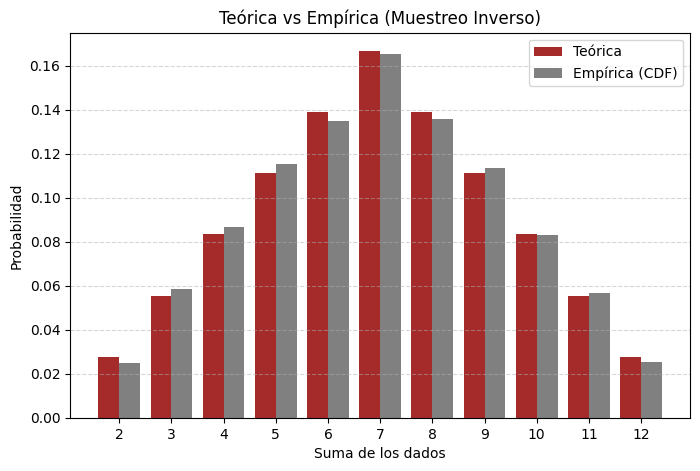

In [47]:
#mas arriba ya habiamos calculado la distribucion teorica, asi que la usamos de nuevo

suma_dados    = np.array(suma_dados) 
prob_teorica = np.array(prob_teorica)   


# definimos el generador congruencial lineal, para generar numeros uniformes en [0,1)
def generador_congruencia_lineal(a, c, M, x1, n):
    numeros = []
    x = x1
    for _ in range(n):
        x = (a * x + c) % M
        numeros.append(x / M)
    return numeros

# aca hacemos exactamente lo mismo que el ejercicio 22, definimos intervalos de probabilidades acumuladas y generamos muestras de la variable aleatoria suma usando el método de la transformada inversa
def generar_sumas_por_cdf(n, a, c, M, x1):
    uniformes = generador_congruencia_lineal(a, c, M, x1, n) 
    cdf       = np.cumsum(prob_teorica) # hacemos la cdf a partir de la pmf teórica 
    muestras  = []
    for r in uniformes:
        for i, pcum in enumerate(cdf):
            if r < pcum:
                muestras.append(suma_dados[i])
                break
    return muestras

# parámetros del generador congruencial lineal
a, c, M, x1 = 1664525, 1013904223, 2**32, 10
n           = 10000

#generamos las muestras de sumas de dados
 
muestras_suma = generar_sumas_por_cdf(N, a, c, M, x1) 

# calculamos la distribución empírica
val, frec = np.unique(muestras_suma, return_counts=True)
prob       = frec / n 

# Comparación gráfica
width = 0.4
plt.figure(figsize=(8,5))

# Barras teóricas
plt.bar(
    suma_dados - width/2,
    prob_teorica,
    width=width,
    label='Teórica',
    color='brown',
)

# Barras empíricas (muestreo inverso)
plt.bar(
    vals_c + width/2,
    prob_c,
    width=width,
    label='Empírica (CDF)',
    color='gray',
)

plt.xticks(suma_dados)
plt.xlabel('Suma de los dados')
plt.ylabel('Probabilidad')
plt.title('Teórica vs Empírica (Muestreo Inverso)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)